# Beginner Matplotlib and Visualization Lab

This lab explains how common charts are drawn. Each chart follows the same pattern: choose the data, choose the x-axis and y-axis, draw the chart, label it, save it, and read the message.

## Important: Use a Python Notebook Runtime

Run this notebook with a **Python 3** kernel in Jupyter, VS Code, JupyterLab, or Google Colab. Do not run these cells in SQL Server, DBeaver, Azure Data Studio SQL query mode, or `sqlcmd`.

If you see SQL Server messages such as `Incorrect syntax near '%'`, the notebook code is being executed by a SQL engine instead of Python.

These beginner notebooks (`05`, `06`, and `07`) do **not** require a database connection. They load `data/beginner_financial_indicators.csv` when the file is present, and automatically create a small fallback dataset when the file is not present, which makes them work in Google Colab.


## 0. Setup

Use this setup cell only inside a Python notebook. `%pip` is valid in Jupyter and Google Colab, but it is not SQL syntax.


In [1]:
%pip install pandas numpy scipy matplotlib seaborn scikit-learn joblib -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")

from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

In [3]:
DATA_PATH = Path("data/beginner_financial_indicators.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def make_fallback_dataset():
    """Create a small dataset only when the CSV file is not available, such as in Colab."""
    dates = pd.date_range("2026-01-01", periods=10, freq="MS")
    templates = [
        ("Bank A", "Maseru", "Commercial Bank", 36.0, 19.5, 3.1, 5.0, 980, 610, 3100),
        ("Bank B", "Leribe", "Commercial Bank", 31.5, 17.4, 4.8, 4.2, 860, 590, 2500),
        ("Bank C", "Mafeteng", "Microfinance", 27.0, 14.8, 6.5, 3.1, 520, 380, 1700),
        ("Bank D", "Quthing", "Microfinance", 23.0, 12.4, 8.2, 2.2, 430, 350, 1350),
    ]
    rows = []
    for month_index, date in enumerate(dates):
        for inst_index, item in enumerate(templates):
            name, region, inst_type, liq, cap, npl, profit, dep, loans, tx = item
            liquidity = liq - month_index * (0.35 + inst_index * 0.08)
            capital = cap - month_index * (0.10 + inst_index * 0.02)
            npl_ratio = npl + month_index * (0.18 + inst_index * 0.05)
            stress = int((liquidity < 24) or (capital < 12) or (npl_ratio > 8.8))
            rows.append({
                "date": date,
                "institution": name,
                "region": region,
                "institution_type": inst_type,
                "liquidity_ratio": round(liquidity, 2),
                "capital_adequacy_ratio": round(capital, 2),
                "npl_ratio": round(npl_ratio, 2),
                "profit_margin": round(profit - npl_ratio * 0.12, 2),
                "total_deposits_m": dep + month_index * (8 - inst_index * 2),
                "total_loans_m": loans + month_index * (6 + inst_index * 2),
                "transaction_count": tx + month_index * (55 - inst_index * 5),
                "stress_flag": stress,
            })
    return pd.DataFrame(rows)


if DATA_PATH.exists():
    # parse_dates tells pandas that the date column should behave like a date, not plain text.
    df = pd.read_csv(DATA_PATH, parse_dates=["date"])
else:
    df = make_fallback_dataset()

print("Rows loaded:", len(df))
display(df.head())

Rows loaded: 41


,date,institution,region,institution_type,liquidity_ratio,capital_adequacy_ratio,npl_ratio,profit_margin,total_deposits_m,total_loans_m,transaction_count,stress_flag
0,2026-01-01,Bank A,Maseru,Commercial Bank,35.60,19.5,3.20,4.62,980,610,3100,0
1,2026-01-01,Bank B,Leribe,Commercial Bank,31.10,17.4,4.90,3.61,860,590,2500,0
2,2026-01-01,Bank C,Mafeteng,Microfinance,26.60,14.8,6.60,2.31,520,380,1700,0
3,2026-01-01,Bank D,Quthing,Microfinance,22.60,12.4,8.30,1.20,430,350,1350,1
4,2026-02-01,Bank A,Maseru,Commercial Bank,35.65,19.4,3.28,4.58,988,616,3155,0


## 1. Load and Clean the Dataset

The chart examples use clean data so missing values do not break the graph or mislead the reader.

In [4]:
print("Rows before cleaning:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Missing values before cleaning:")
display(df.isna().sum())

# Work on a copy so the raw data stays unchanged.
clean_df = df.drop_duplicates().copy()

numeric_cols = [
    "liquidity_ratio",
    "capital_adequacy_ratio",
    "npl_ratio",
    "profit_margin",
    "total_deposits_m",
    "total_loans_m",
    "transaction_count",
]

# Convert numeric columns safely. Bad values become NaN so they can be filled.
for column in numeric_cols:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

# Fill missing numeric values with the median. The median is simple and less affected by outliers.
clean_df[numeric_cols] = clean_df[numeric_cols].fillna(clean_df[numeric_cols].median())

print("Rows after cleaning:", len(clean_df))
print("Missing values after cleaning:")
display(clean_df.isna().sum())
display(clean_df.head())

Rows before cleaning: 41
Duplicate rows: 1
Missing values before cleaning:


date                      0
institution               0
region                    0
institution_type          0
liquidity_ratio           1
capital_adequacy_ratio    0
npl_ratio                 1
profit_margin             1
total_deposits_m          0
total_loans_m             0
transaction_count         0
stress_flag               0
dtype: int64

Rows after cleaning: 40
Missing values after cleaning:


date                      0
institution               0
region                    0
institution_type          0
liquidity_ratio           0
capital_adequacy_ratio    0
npl_ratio                 0
profit_margin             0
total_deposits_m          0
total_loans_m             0
transaction_count         0
stress_flag               0
dtype: int64

,date,institution,region,institution_type,liquidity_ratio,capital_adequacy_ratio,npl_ratio,profit_margin,total_deposits_m,total_loans_m,transaction_count,stress_flag
0,2026-01-01,Bank A,Maseru,Commercial Bank,35.60,19.5,3.20,4.62,980,610,3100,0
1,2026-01-01,Bank B,Leribe,Commercial Bank,31.10,17.4,4.90,3.61,860,590,2500,0
2,2026-01-01,Bank C,Mafeteng,Microfinance,26.60,14.8,6.60,2.31,520,380,1700,0
3,2026-01-01,Bank D,Quthing,Microfinance,22.60,12.4,8.30,1.20,430,350,1350,1
4,2026-02-01,Bank A,Maseru,Commercial Bank,35.65,19.4,3.28,4.58,988,616,3155,0


## 2. Line Chart

Use a line chart when the x-axis has time order. The line is drawn by connecting each point from left to right.

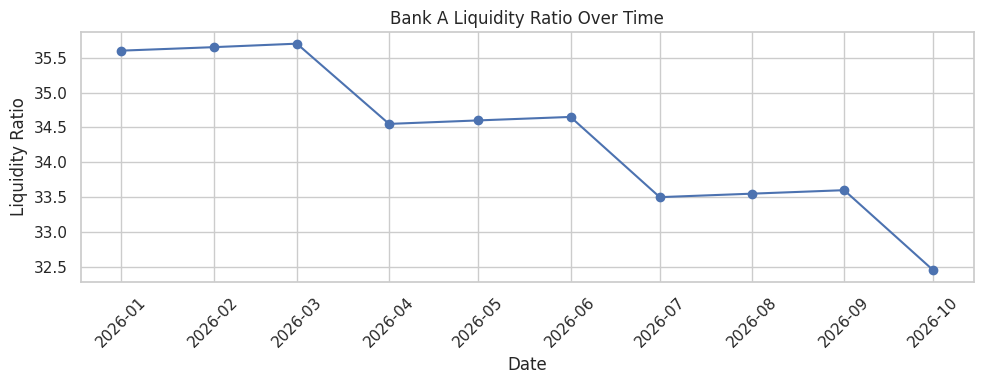

In [5]:
bank_a = clean_df[clean_df["institution"] == "Bank A"].sort_values("date")

plt.figure(figsize=(10, 4))
plt.plot(
    bank_a["date"],              # x-axis: time
    bank_a["liquidity_ratio"],   # y-axis: value over time
    marker="o",                  # marker shows each actual observation
    linewidth=1.5,
)
plt.title("Bank A Liquidity Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Liquidity Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_line_chart.png", dpi=150)
plt.show()

## 3. Scatter Plot

Use a scatter plot to compare two numeric columns. Each dot is one row in the dataset.

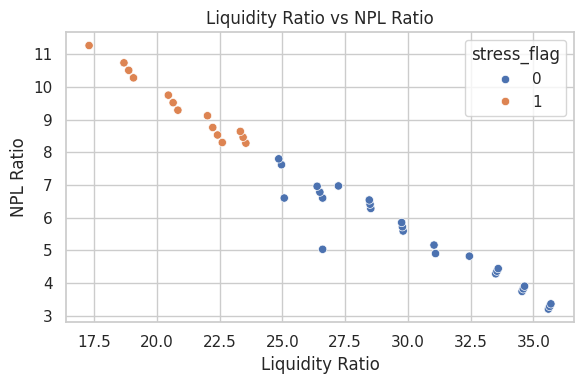

In [6]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=clean_df,
    x="liquidity_ratio",         # horizontal position of each dot
    y="npl_ratio",               # vertical position of each dot
    hue="stress_flag",           # color shows the stress category
)
plt.title("Liquidity Ratio vs NPL Ratio")
plt.xlabel("Liquidity Ratio")
plt.ylabel("NPL Ratio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_scatter_plot.png", dpi=150)
plt.show()

## 4. Histogram

Use a histogram to see the distribution of one numeric column. The bars count how many values fall inside each range.

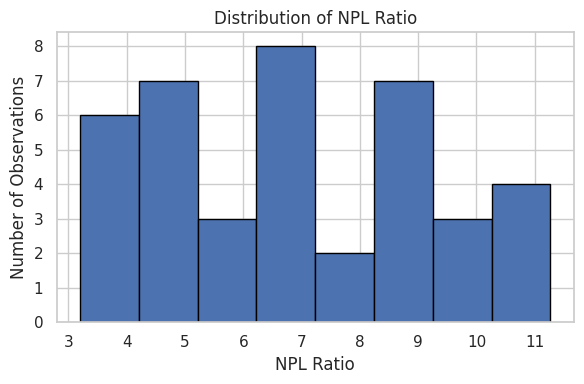

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(
    clean_df["npl_ratio"],
    bins=8,                      # number of value ranges
    edgecolor="black",           # visible bar borders
)
plt.title("Distribution of NPL Ratio")
plt.xlabel("NPL Ratio")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_histogram.png", dpi=150)
plt.show()

## 5. Box Plot and Outliers

Use a box plot to compare spread and possible outliers. Points beyond the whiskers deserve review; they are not automatically wrong.

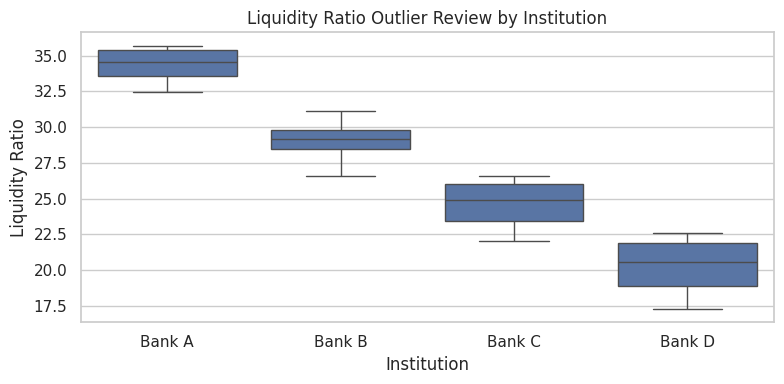

Lower limit: 9.23
Upper limit: 44.76


,date,institution,liquidity_ratio


In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=clean_df, x="institution", y="liquidity_ratio")
plt.title("Liquidity Ratio Outlier Review by Institution")
plt.xlabel("Institution")
plt.ylabel("Liquidity Ratio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_boxplot_outliers.png", dpi=150)
plt.show()

# IQR is a simple outlier rule often used with box plots.
q1 = clean_df["liquidity_ratio"].quantile(0.25)
q3 = clean_df["liquidity_ratio"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = clean_df[(clean_df["liquidity_ratio"] < lower_limit) | (clean_df["liquidity_ratio"] > upper_limit)]
print("Lower limit:", round(lower_limit, 2))
print("Upper limit:", round(upper_limit, 2))
display(outliers[["date", "institution", "liquidity_ratio"]])

## 6. Vertical Bar Chart

Use a vertical bar chart to compare categories. Here each bar is one institution's average liquidity.

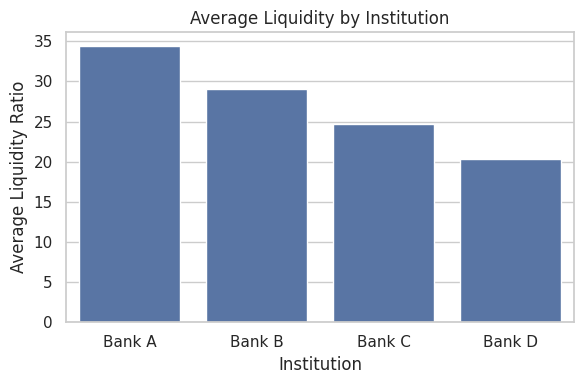

In [9]:
avg_liquidity = clean_df.groupby("institution", as_index=False)["liquidity_ratio"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(data=avg_liquidity, x="institution", y="liquidity_ratio")
plt.title("Average Liquidity by Institution")
plt.xlabel("Institution")
plt.ylabel("Average Liquidity Ratio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_vertical_bar.png", dpi=150)
plt.show()

## 7. Horizontal Bar Chart

Use a horizontal bar chart when category names may be long or ranking is important.

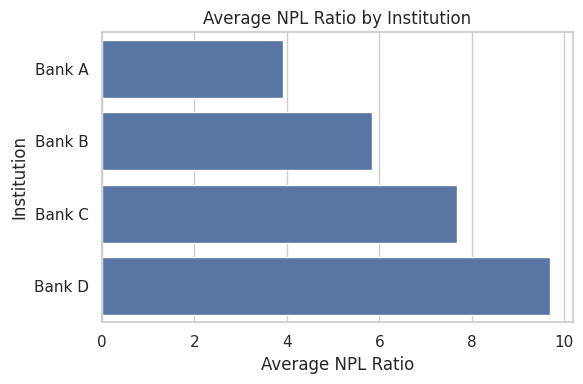

In [10]:
avg_npl = clean_df.groupby("institution", as_index=False)["npl_ratio"].mean()
avg_npl = avg_npl.sort_values("npl_ratio")

plt.figure(figsize=(6, 4))
sns.barplot(data=avg_npl, x="npl_ratio", y="institution", orient="h")
plt.title("Average NPL Ratio by Institution")
plt.xlabel("Average NPL Ratio")
plt.ylabel("Institution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_horizontal_bar.png", dpi=150)
plt.show()

## 8. Heatmap

Use a heatmap to show a matrix with color. A correlation heatmap makes strong positive and negative relationships easy to scan.

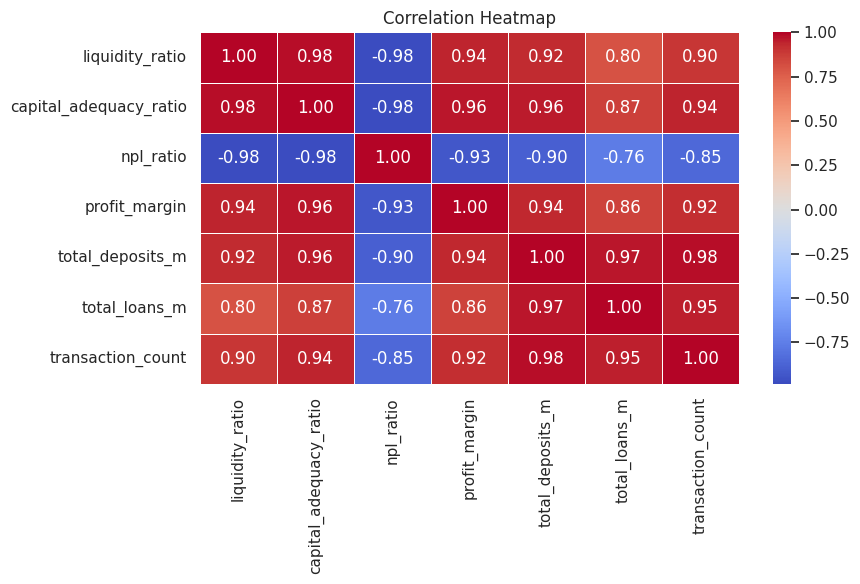

In [11]:
corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,                  # write the number inside each square
    cmap="coolwarm",             # blue to red color scale
    fmt=".2f",                   # show two decimals
    linewidths=0.5,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_correlation_heatmap.png", dpi=150)
plt.show()

## 9. Confusion Matrix Heatmap

A confusion matrix compares actual classes with predicted classes. It is usually drawn as a heatmap so large counts stand out.

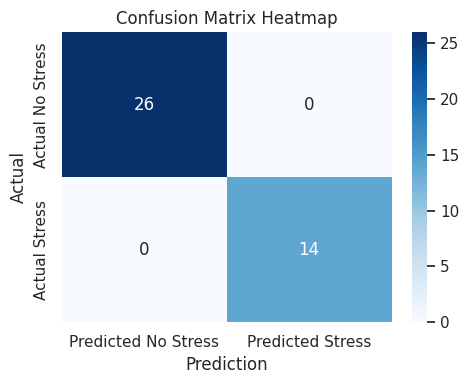

In [12]:
actual = clean_df["stress_flag"]

# Beginner rule-based prediction: predict stress if liquidity is low or NPL is high.
predicted = ((clean_df["liquidity_ratio"] < 24) | (clean_df["npl_ratio"] > 8.8)).astype(int)

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Stress", "Predicted Stress"],
    yticklabels=["Actual No Stress", "Actual Stress"],
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_confusion_matrix_heatmap.png", dpi=150)
plt.show()

## 10. Small Dashboard with Subplots

Subplots place multiple charts in one figure. Use this when charts answer related questions.

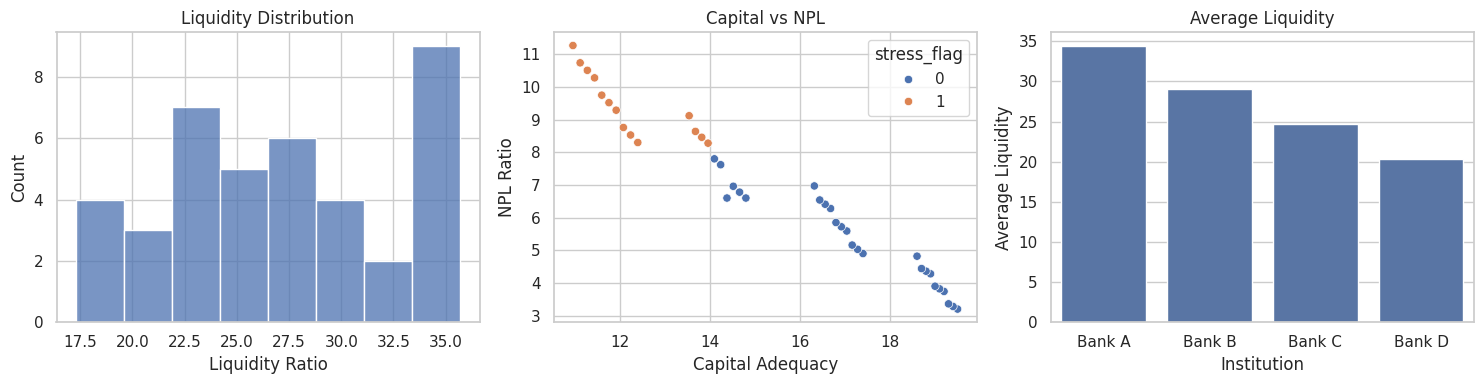

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(clean_df["liquidity_ratio"], bins=8, ax=axes[0])
axes[0].set_title("Liquidity Distribution")
axes[0].set_xlabel("Liquidity Ratio")

sns.scatterplot(data=clean_df, x="capital_adequacy_ratio", y="npl_ratio", hue="stress_flag", ax=axes[1])
axes[1].set_title("Capital vs NPL")
axes[1].set_xlabel("Capital Adequacy")
axes[1].set_ylabel("NPL Ratio")

sns.barplot(data=avg_liquidity, x="institution", y="liquidity_ratio", ax=axes[2])
axes[2].set_title("Average Liquidity")
axes[2].set_xlabel("Institution")
axes[2].set_ylabel("Average Liquidity")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_visual_dashboard.png", dpi=150)
plt.show()